In [1]:
# ============================================================
# IMPORTS AND CONSTANTS
# ============================================================
# Standard numerical and plotting libraries.
# matplotlib.patches.Rectangle: used to draw the superconductor geometry outline on plots.
# mumax3PP: custom post-processing library for mumax3 micromagnetic simulation output:
#   - ovf:             reads .ovf vector-field snapshot files
#   - parameters:      constructs OVF file naming/metadata descriptors
#   - fft_across_xyzm: spatiotemporal FFT (not used here, imported for consistency)
# Physical constants defined as short aliases for convenience.
import numpy as np
from matplotlib import rc
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

%matplotlib inline
import multiprocessing as mp
import matplotlib.colors as colors
import scipy.optimize as opt
from scipy.signal import find_peaks
import mumax3PP.ovf as ovf
import mumax3PP.parameters as parameters
import mumax3PP.fft_across_xyzm as FFT_across_xyzm
import matplotlib.patches as patches
# import mumax3PP.plotsRGB as pltRGB
import imageio

import glob
import os.path
import time
from os import path
from IPython.display import clear_output

import time

sqrt = np.sqrt
pi = np.pi
exp = np.exp
sin = np.sin
cos = np.cos
mu0 = pi*4e-7

In [2]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================
# findNearest(array, value):
#   Returns the index and value of the element in  closest to .
#   Useful for picking a specific spatial position or frequency bin.
#
# gedDT(times):
#   Robustly estimates the time step dt from a (possibly jittered) time array
#   by fitting a linear model t = a*i + b via least squares and returning slope a.
def findNearest(array,value):
    idx = (np.abs(array-value)).argmin()
    return idx, array[idx]

def gedDT(times):
    xdata = range(len(times))
    from scipy.optimize import curve_fit
    def func(x, a, b):
        return a * x + b
    dt=np.abs(times[-1]-times[1])/(len(times)-1)
    popt, pcov = curve_fit(func, xdata, times, p0=[dt,0])
#     plt.plot(xdata, times)
#     plt.plot(xdata, func(xdata, *popt))
    return popt[0]

In [4]:
# ============================================================
# LATEX RENDERING
# ============================================================
# Enable LaTeX text rendering in matplotlib so that axis labels and annotations
# are typeset with full LaTeX quality (required for publication-ready figures).
plt.rcParams.update({'text.usetex': True,})

In [5]:
# ============================================================
# GLOBAL FIGURE STYLE
# ============================================================
# Set publication-style figure parameters:
#   - Font: Arial 11 pt (common for journal figures)
#   - linewidth: thin axis/tick lines (0.5 pt) for a clean, minimal look
#   - pic_width/pic_height: figure dimensions converted from mm to inches,
#     scaled to an 8.8 mm journal column width (standard for two-column papers)
#   - mini / maxi: symmetric colour scale limits for the stray field map (±1 mT)
#   - d = 1e9: conversion factor from metres to nanometres for axis labels
plt.rcParams.update({'font.size': 11})
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

linewidth  = 0.5
plt.rcParams['axes.linewidth'] = linewidth
plt.rcParams['xtick.major.width'] = linewidth
plt.rcParams['ytick.major.width'] = linewidth

width = 8.8
pic_width = (width*0.4)/2.54
pic_height = (width/3)/2.54

mini = -1.0    #-1*np.abs(colormap).max()/1e-3
maxi = 1.0    # 1*np.abs(colormap).max()/1e-3
d = 1e9

In [6]:
(width/3)/2.54

1.1548556430446195

Reading folder: C:\Users\admin\Documents\mumax3\superconductor\stray_field\GaYIG_w_800nm_B0_90mT_ref.out/B_demag000000*.ovf
N of files to process:  1
Available nodes (n-1): 31
Matrix shape: (1, 128, 1, 4096, 3)
(1, 128, 1, 4096, 3)
Reading folder: C:\Users\admin\Documents\mumax3\superconductor\stray_field\GaYIG_w_800nm_B0_90mT.out/B_demag000000*.ovf
N of files to process:  1
Available nodes (n-1): 31
Matrix shape: (1, 128, 1, 4096, 3)
(1, 128, 1, 4096, 3)


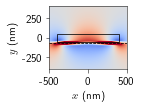

In [11]:
# ============================================================
# LOAD STRAY FIELD DATA AND COMPUTE DIFFERENCE MAP
# ============================================================
# Load two mumax3 demagnetisation field snapshots for a GaYIG film:
#   B_ref:  demagnetisation field WITHOUT the superconductor present (reference run)
#   B_stat: demagnetisation field WITH the superconductor present
#
# Both runs share the same geometry: strip width =  nm, bias field =  mT.
# The head "B_demag000000" selects the static (t=0) snapshot of the demag field.
#
# x, y, z coordinate arrays are built from the OVF cell sizes and centred at zero.
#
# colormap = B_stat - B_ref (z-component, comp=2):
#   This difference isolates the stray field contribution of the superconductor,
#   removing the self-demagnetisation of the GaYIG film that is present in both runs.
#
# The 2D colour map is plotted in the x-z plane (y = 0 slice):
#   - coolwarm colormap: blue = field decrease, red = field increase
#   - Rectangle patch: outlines the superconductor cross-section (width x 100 nm,
#     positioned 70-50=20 nm above z=0, i.e. 20 nm above the magnetic film surface)
#   - Dashed horizontal line at z=0: marks the top surface of the GaYIG film
#   - y0 = -70 nm offset: shifts the y-tick labels so that z=0 corresponds to the
#     film surface in the displayed coordinate system
#   - Colour scale: ±1 mT (mini/maxi), units converted to mT via /1e-3
width = 800
B = 90

dir0 = r"C:\Users\admin\Documents\mumax3\superconductor\stray_field\GaYIG_w_{}nm_B0_{}mT_ref.out".format(width, B)

parms = parameters.ovfParms(head="B_demag000000", )
M_tzyxm = ovf.OvfFile(dir0, parms)
print((M_tzyxm.array).shape)

B_ref = M_tzyxm.array[:,:,:,:,:]

dir0 = r"C:\Users\admin\Documents\mumax3\superconductor\stray_field\GaYIG_w_{}nm_B0_{}mT.out".format(width, B)

parms = parameters.ovfParms(head="B_demag000000", )
M_tzyxm = ovf.OvfFile(dir0, parms)
print((M_tzyxm.array).shape)

B_stat = M_tzyxm.array[:,:,:,:,:]

cx = M_tzyxm._headers["xstepsize"]
x = np.arange(0, M_tzyxm.array.shape[3]*cx-cx/10,cx)
x -= x.max()/2

cy = M_tzyxm._headers["ystepsize"]
y = np.arange(0, M_tzyxm.array.shape[2]*cy-cy/10,cy)
y -= y.max()/2

cz = M_tzyxm._headers["zstepsize"]
z = np.arange(0, M_tzyxm.array.shape[1]*cz-cz/10,cz)
z -= z.max()/2

comp = 2
colormap =  B_stat[0,:,0,:,comp]  -  B_ref[0,:,0,:,comp]    



# 50e-9 - 10e-9 - 10e-9

plt.figure(figsize=(pic_width,pic_height))
im = plt.imshow( colormap/1e-3, origin="lower", aspect="auto", cmap="coolwarm", vmin=mini, vmax=maxi,
          extent=[x.min()*d,x.max()*d,z.min()*d,z.max()*d,], interpolation="gaussian"       )
plt.gca().add_patch(Rectangle((-width/2, 70-50), width, 100,  edgecolor='k',  facecolor='none',  lw=0.75 ))
#         plt.colorbar(im, shrink=0.25, aspect=5, orientation="horizontal", pad=.99, anchor=(1, 0))
plt.axhline( 0, ls="--", lw=0.75, c="k" )
plt.xlabel(r"$x$ (nm)")
plt.ylabel(r"$y$ (nm)")
y0 = -70
yticks = np.array([-250, 0, 250])
plt.yticks(yticks-y0, yticks, )
xticks = np.array([-500, 0, 500])
plt.xticks(xticks, xticks, )
plt.xlim(-500, 500)
plt.ylim(-400-y0, 400-y0)
# plt.savefig( r"C:\Users\admin\Desktop\\"+dir0.split("\\")[-1][:-4]+f".pdf",bbox_inches='tight',pad_inches = 0,dpi=600,facecolor='w', )
plt.show()

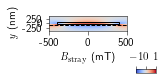

In [12]:
# ============================================================
# PUBLICATION FIGURE — STRAY FIELD MAP WITH COLORBAR
# ============================================================
# Identical field-difference map as Cell 5, but formatted for publication:
#   - x-axis label changed to the field quantity B_stray (mT) — note: this label
#     appears to be intended for the colorbar axis rather than the x spatial axis;
#     check axis assignment if reusing this cell.
#   - A horizontal colorbar is added below the figure:
#       shrink=0.25, aspect=5: makes the bar compact and narrow
#       pad=0.6, anchor=(1.5, 0): positions it to the right of the plot area
#       Tick marks and labels are placed on the TOP edge of the colorbar
#       (labeltop=True, labelbottom=False) for a cleaner layout.
#   - The commented-out savefig line saves the figure as a PDF at 600 dpi
#     for direct use in a manuscript.
plt.figure(figsize=(pic_width,pic_height))
im = plt.imshow( colormap/1e-3, origin="lower", aspect="auto", cmap="coolwarm", vmin=mini, vmax=maxi,
          extent=[x.min()*d,x.max()*d,z.min()*d,z.max()*d,], interpolation="gaussian"       )
plt.gca().add_patch(Rectangle((-width/2, 70-50), width, 100,  edgecolor='k',  facecolor='none',  lw=1 ))
#         plt.colorbar(im, shrink=0.25, aspect=5, orientation="horizontal", pad=.99, anchor=(1, 0))
plt.axhline( 0, ls="--", lw=0.99, c="k" )
plt.xlabel(r"$\it{B}_\mathrm{stray}$ (mT)")
plt.ylabel(r"$\it{y}$ (nm)")
y0 = -70
yticks = np.array([-250, 0, 250])
plt.yticks(yticks-y0, yticks, )
xticks = np.array([-500, 0, 500])
plt.xticks(xticks, xticks, )
plt.xlim(-500, 500)
plt.ylim(-400-y0, 400-y0)

cbar = plt.colorbar(im, shrink=0.25, aspect=5, orientation="horizontal",pad=.6, anchor=(1.5, 0),)
cbar.ax.tick_params( bottom=False, top=True, labelbottom=False, labeltop=True, )
        
# plt.savefig( r"C:\Users\admin\Desktop\\"+dir0.split("\\")[-1][:-4]+f"_leg.pdf",bbox_inches='tight',pad_inches = 0,dpi=600,facecolor='w', )
plt.show()